# DREAM Model Evaluation
Reproduces Table 4 in Tiyajamorn et al. (EMNLP 2021).

**Tasks:**
1. Pearson correlation trên STS-2017 — backbone vs DREAM
2. t-SNE visualization của language embeddings theo ngôn ngữ

In [19]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass

import pandas as pd
import glob
from torch.cuda import is_available
from scipy.stats import pearsonr
from numpy import ndarray, diag

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR / 'src'))

from dream.pipeline import DREAMPipeline

In [2]:
BACKBONE_NAME = "sentence-transformers/LaBSE"
CHECKPOINT_PATH = f"{PROJECT_DIR}/checkpoints/dream_best.pt"
STS17_PATH = f"{PROJECT_DIR}/data/STS17"

DEVICE = 'cuda' if is_available() else 'cpu'

# Load Models

In [3]:
dream_pipeline = DREAMPipeline.from_pretrained(checkpoint_path=CHECKPOINT_PATH, backbone_name=BACKBONE_NAME, device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Load Evaluate Data

In [4]:
@dataclass
class STS17Embedding:
    lang_pairs  : str
    sent1       : list[str]
    sent2       : list[str]
    similarity  : list[float]

    emb_sent1_backbone  : ndarray
    emb_sent2_backbone  : ndarray

    emb_sent1_dream     : ndarray
    emb_sent2_dream     : ndarray
    lang_sent1_dream    : ndarray
    lang_sent2_dream    : ndarray


def load_sts17(path: str, pipeline: DREAMPipeline, batch_size: int) -> list[STS17Embedding]:
    all_txts = glob.glob(f'{path}/STS.*.txt')

    if len(all_txts) == 0:
        raise FileNotFoundError('Cannot find any files.')
    
    result = []
    for txt in all_txts:
        lang_pairs = txt.split('.')[-2]
        df = pd.read_csv(txt, sep='\t', header=None, names=['sent1', 'sent2', 'sim'], on_bad_lines='skip')
        
        # English column first
        (sent1, sent2) = (df['sent1'].tolist(), df['sent2'].tolist()) if lang_pairs.startswith('en') else (df['sent2'].tolist(), df['sent1'].tolist())

        emb_sent1_backbone = pipeline.encode(sent1, batch_size=batch_size, only_backbone=True)
        emb_sent2_backbone = pipeline.encode(sent2, batch_size=batch_size, only_backbone=True)

        emb_sent1_dream, lang_sent1_dream, _ = pipeline.dream_forward(sent1, batch_size=batch_size)
        emb_sent2_dream, lang_sent2_dream, _ = pipeline.dream_forward(sent2, batch_size=batch_size)
        
        
        result.append(STS17Embedding(lang_pairs=lang_pairs,
                                     sent1=sent1,
                                     sent2=sent2,
                                     similarity=df['sim'].astype(float).tolist(),

                                     emb_sent1_backbone=emb_sent1_backbone,
                                     emb_sent2_backbone=emb_sent2_backbone,

                                     emb_sent1_dream=emb_sent1_dream,
                                     emb_sent2_dream=emb_sent2_dream,
                                     lang_sent1_dream=lang_sent1_dream,
                                     lang_sent2_dream=lang_sent2_dream
                                    ))
    
    return result

In [5]:
sts17 = load_sts17(STS17_PATH, dream_pipeline, 64)
len(sts17)

7

# STS17 Evaluation

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

def pairwise_cosine_sim(a, b):
    return diag(cosine_similarity(a, b))

In [26]:
results = {}
for data in sts17:
    # Cosine similarity từng cặp (đã normalize → chỉ cần dot product)
    backbone_sim = pairwise_cosine_sim(data.emb_sent1_backbone, data.emb_sent2_backbone)
    dream_sim    = pairwise_cosine_sim(data.emb_sent1_dream,    data.emb_sent2_dream)
    
    # Pearson correlation với ground truth
    results[data.lang_pairs] = {
        "backbone": pearsonr(backbone_sim, data.similarity)[0],
        "dream":    pearsonr(dream_sim,    data.similarity)[0],
    }

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df['avg'] = results_df.mean(axis=1).round(4)

results_df

,en-ar,en-de,en-tr,es-en,fr-en,it-en,nl-en,avg
backbone,0.7217,0.7407,0.7294,0.6547,0.7628,0.7652,0.7502,0.7321
dream,0.6941,0.7100,0.7188,0.6530,0.7429,0.7458,0.7386,0.7147


# Multilingual Embedding

In [7]:
# ── Cell: t-SNE helper ────────────────────────────────────────
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

TSNE_N = 250   # số câu mỗi ngôn ngữ

def run_tsne(emb_src: np.ndarray, emb_trg: np.ndarray, n: int = TSNE_N):
    """
    Sample n điểm từ mỗi ngôn ngữ rồi chạy t-SNE.
    Returns: coords (2n, 2), labels (2n,) — 0=src, 1=trg
    """
    idx_src = np.random.choice(len(emb_src), min(n, len(emb_src)), replace=False)
    idx_trg = np.random.choice(len(emb_trg), min(n, len(emb_trg)), replace=False)
    stacked = np.vstack([emb_src[idx_src], emb_trg[idx_trg]])
    labels  = np.array([0] * len(idx_src) + [1] * len(idx_trg))
    coords  = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000).fit_transform(stacked)
    return coords, labels

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifol

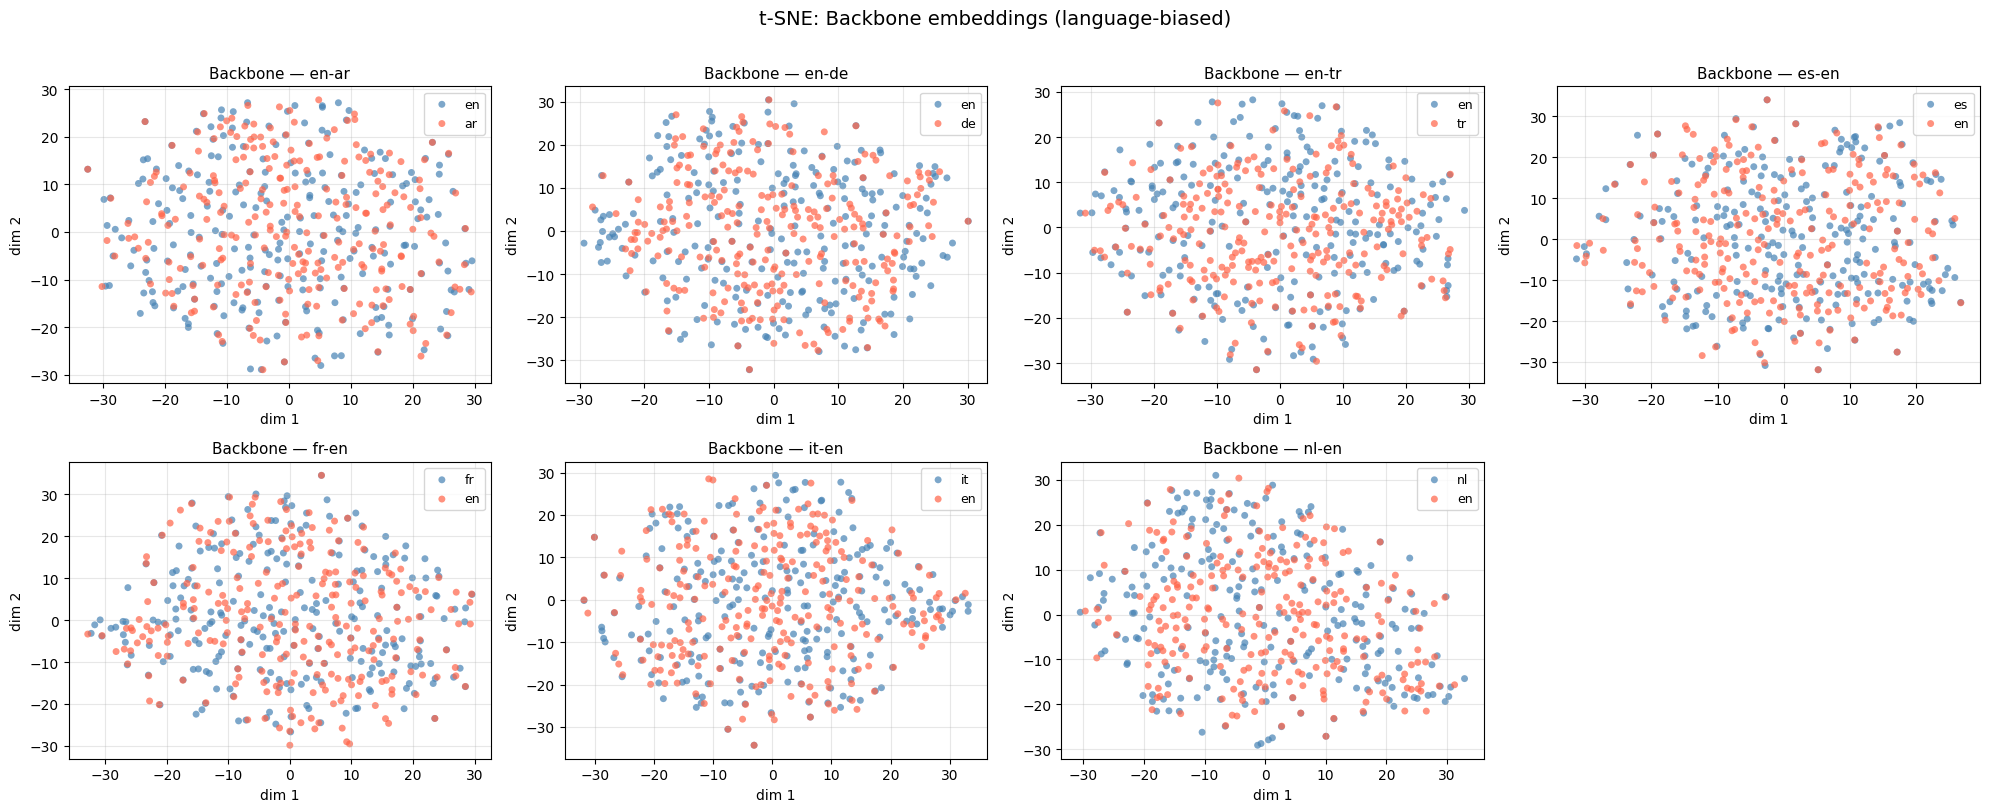

In [8]:
# ── Cell: plot backbone (language-biased) ─────────────────────
# Mục tiêu: thấy 2 cluster riêng biệt → backbone còn language-biased

n_pairs = len(sts17)
ncols   = 4
nrows   = (n_pairs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, data in zip(axes, sts17):
    src_lang, trg_lang = data.lang_pairs.split("-")

    # emb_sent1_backbone / emb_sent2_backbone: đã normalize, shape (N, D)
    coords, labels = run_tsne(data.emb_sent1_backbone, data.emb_sent2_backbone)

    ax.scatter(coords[labels==0, 0], coords[labels==0, 1],
               c="steelblue", label=src_lang, alpha=0.7, s=25, edgecolors="none")
    ax.scatter(coords[labels==1, 0], coords[labels==1, 1],
               c="tomato",    label=trg_lang, alpha=0.7, s=25, edgecolors="none")

    ax.set_title(f"Backbone — {data.lang_pairs}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

fig.suptitle("t-SNE: Backbone embeddings (language-biased)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("tsne_backbone.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifol

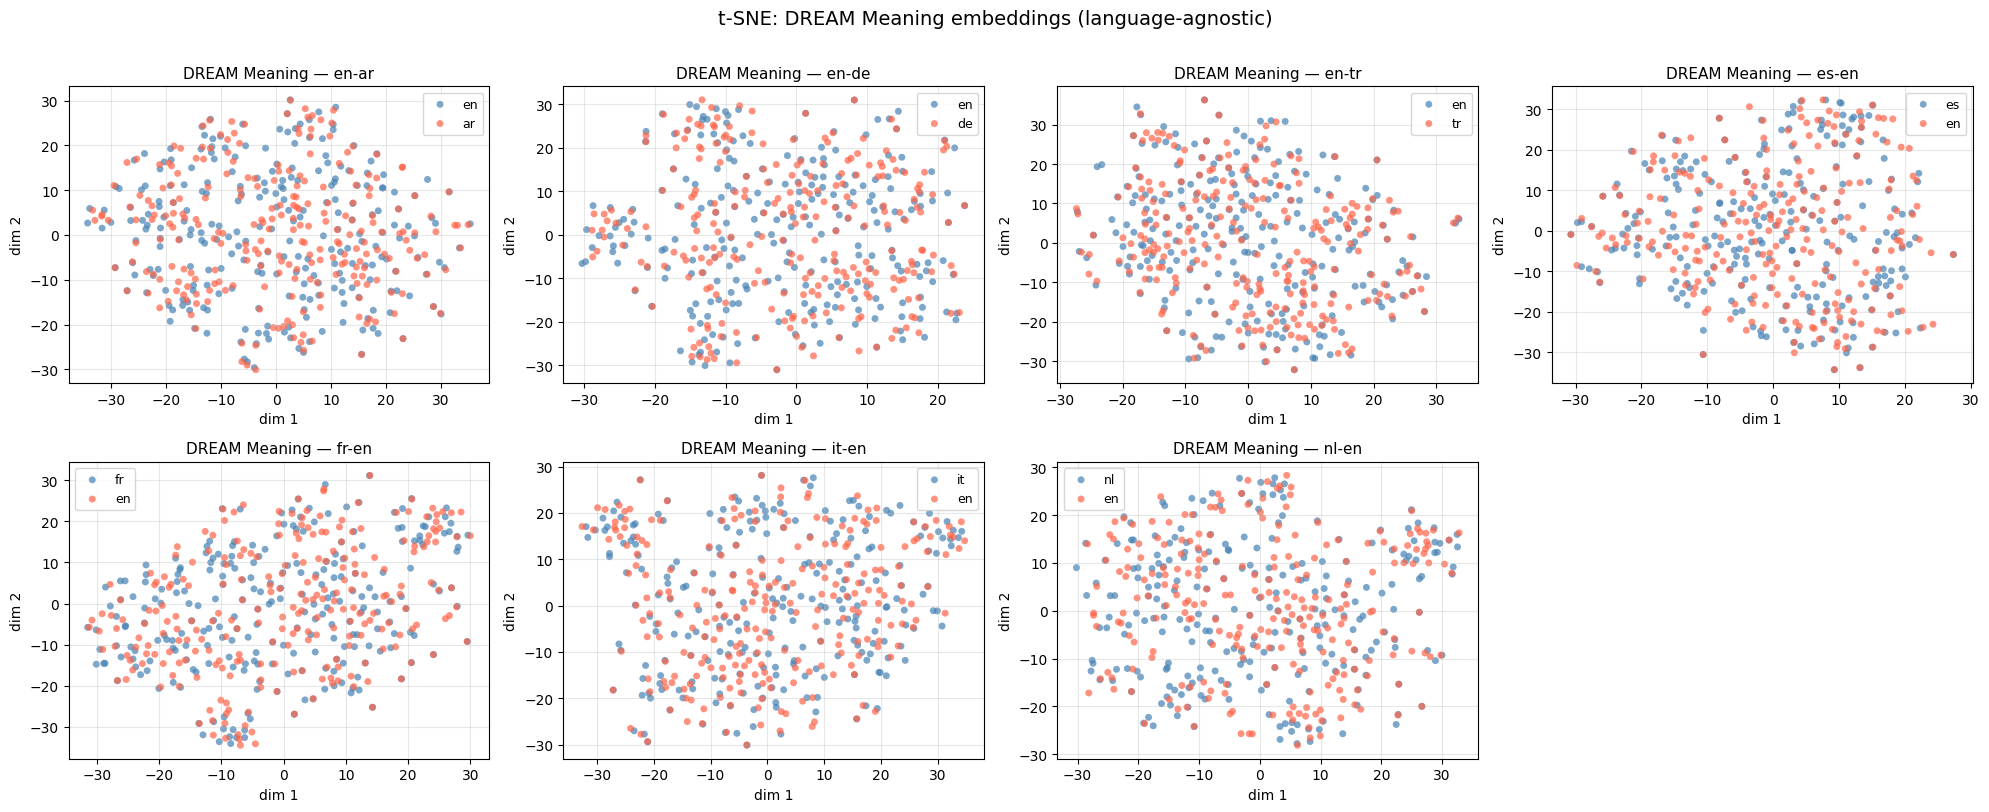

In [9]:
# ── Cell: plot DREAM meaning (language-agnostic) ──────────────
# Mục tiêu: 2 ngôn ngữ trộn vào nhau → meaning space không còn phân tách theo ngôn ngữ

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, data in zip(axes, sts17):
    src_lang, trg_lang = data.lang_pairs.split("-")

    coords, labels = run_tsne(data.emb_sent1_dream, data.emb_sent2_dream)

    ax.scatter(coords[labels==0, 0], coords[labels==0, 1],
               c="steelblue", label=src_lang, alpha=0.7, s=25, edgecolors="none")
    ax.scatter(coords[labels==1, 0], coords[labels==1, 1],
               c="tomato",    label=trg_lang, alpha=0.7, s=25, edgecolors="none")

    ax.set_title(f"DREAM Meaning — {data.lang_pairs}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

fig.suptitle("t-SNE: DREAM Meaning embeddings (language-agnostic)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("tsne_dream_meaning.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifol

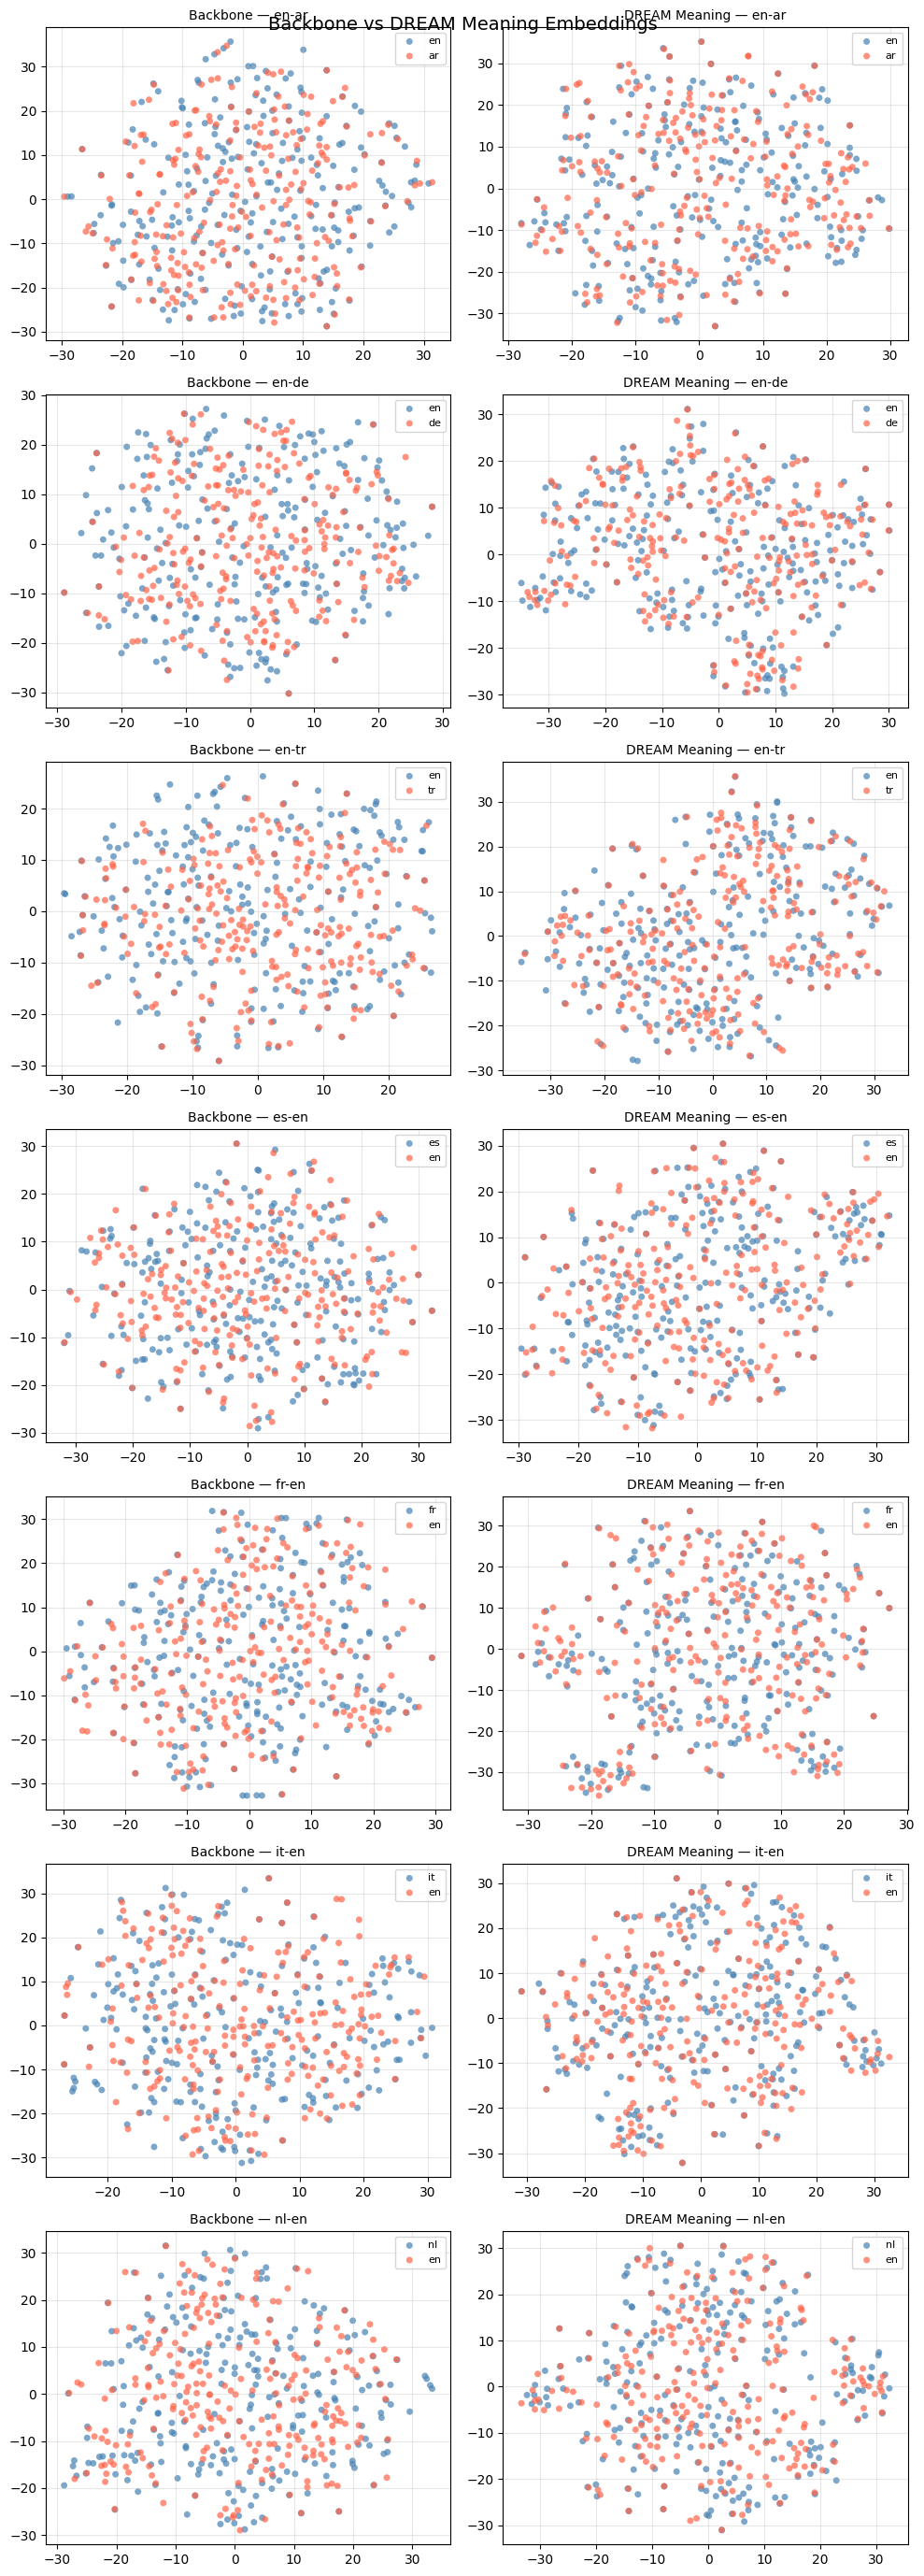

In [10]:
# ── Cell: side-by-side comparison per pair ────────────────────
# Backbone (trái) vs DREAM (phải) — giống Figure 5 trong paper

fig, axes = plt.subplots(n_pairs, 2, figsize=(10, 4 * n_pairs))

for row, data in enumerate(sts17):
    src_lang, trg_lang = data.lang_pairs.split("-")

    for col, (emb1, emb2, title) in enumerate([
        (data.emb_sent1_backbone, data.emb_sent2_backbone, "Backbone"),
        (data.emb_sent1_dream,    data.emb_sent2_dream,    "DREAM Meaning"),
    ]):
        ax     = axes[row, col]
        coords, labels = run_tsne(emb1, emb2)

        ax.scatter(coords[labels==0, 0], coords[labels==0, 1],
                   c="steelblue", label=src_lang, alpha=0.7, s=25, edgecolors="none")
        ax.scatter(coords[labels==1, 0], coords[labels==1, 1],
                   c="tomato",    label=trg_lang, alpha=0.7, s=25, edgecolors="none")

        ax.set_title(f"{title} — {data.lang_pairs}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Backbone vs DREAM Meaning Embeddings", fontsize=14)
plt.tight_layout()
plt.savefig("tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Meaning Embedding